**The key problem to be addressed, in analyzing the given Housing Price Dataset, is to identify the variables that contribute most significantly to property prices. These include a number of features: bedrooms, bathrooms, size of living area, lot size, number of floors, geographic location latitude and longitude, and other attributes such as waterfront view, condition, and whether renovated or not. Which of these features is most influential in determining housing prices and, therefore, shows the trends and patterns in the market? These factors will be crucial to understand several decision points in many real estate investors', buyers', and policy makers' decision-making. It will also reveal price trends across various geographic regions and property features useful in predicting prices of properties by predictive modeling techniques, along with recommending systems in line with the preferences of homebuyers.**


 After analysis , each question is in a seperate section with its answers .
you can use the table of content powered by google colab

```
sections  pointed down
```




1-DATA PREPROCESSING

```

```



2-EDA

```

```


3-What is the average price of properties listed in each zip code?

Notes according to what we see in the table
```

```


4-How does the number of bedrooms affect the average price?


```

```


5-Are properties with a waterfront view significantly more expensive than those without?

```
```


6-Examine the relationship between the size of the living area ( sqft_living )and the price.


```

```


7-How does the condition ( condition ) influence the property price?


```

```


8-Are newer properties in the feature year built( yr_built ) priced differently compared to older ones?

```

```


9-Is there a noticeable difference in prices between properties with and without a basement ( sqft_basement )?
Analyze if properties in areas with larger sqft_lot15 have higher average prices.

```

```


10-Investigate whether properties in certain geographic locations (based on lat and long ) are more expensive.
```

```

11-Determine if properties with more floors ( floors ) tend to have higher or lower prices.


In [1]:
#python version
!python --version

Python 3.10.12


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from IPython.display import display
import matplotlib.ticker as ticker



In [3]:
df=pd.read_csv('/content/Housing.csv')

# DATA PREPROCESSING

In [4]:
df.columns = df.columns.str.strip() #remove space from columns name to avoid name conflicts

In [5]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [6]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [7]:
df.shape

(21613, 21)

In [8]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580306e+09,5.400886e+05,3.370795,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876570e+09,3.671268e+05,0.930105,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [9]:
df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


In [10]:
df.duplicated().sum()

0

# EDA

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [12]:
#change the format of 'price' column  with $ sign
#The price is the target of our analysis
#the change will be done on diff dataframe that is a copy of the original
dff=df.copy()
print('There are', len(df['price'].unique()), 'different house prices.')
dff['price'] = df['price'].apply(lambda x: '${:,.2f}'.format(x))
dff['price'].head()

There are 4029 different house prices.


,price
0,"$231,300.00"
1,"$538,000.00"
2,"$180,000.00"
3,"$604,000.00"
4,"$510,000.00"


In [13]:
'''
# logistic regression to get features importance to the price target
# very high time complexity = 3 min so i will put the output i get as a text feel free to run the code
# a copy of the df
logisticdata = df.copy()

# Split the data into features (X) and target (y)
X = logisticdata.drop(columns=['id','price','date'] , errors='ignore')
y = logisticdata['price']  # Replace 'target_column' with the name of the target variable

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# S Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

#  Extracting feature importances (coefficients)
importances = pd.DataFrame(data={
    'Attribute': X_train.columns,
    'Importance': model.coef_[0]
})

#  Sorting features by importance
importances = importances.sort_values(by='Importance', ascending=False)

#  Plot the importances
plt.bar(x=importances['Attribute'], height=importances['Importance'], color='#087E8B')
plt.title('Feature Importances Obtained from Coefficients', size=20)
plt.xticks(rotation='vertical')
plt.show()

'''

"\n# logistic regression to get features importance to the price target\n# very high time complexity = 3 min so i will put the output i get as a text feel free to run the code\n# a copy of the df\nlogisticdata = df.copy()\n\n# Split the data into features (X) and target (y)\nX = logisticdata.drop(columns=['id','price','date'] , errors='ignore')\ny = logisticdata['price']  # Replace 'target_column' with the name of the target variable\n\n# Train/test split\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)\n\n# S Scale the features\nscaler = StandardScaler()\nX_train_scaled = scaler.fit_transform(X_train)\nX_test_scaled = scaler.transform(X_test)\n\n#  Train Logistic Regression model\nmodel = LogisticRegression()\nmodel.fit(X_train_scaled, y_train)\n\n#  Extracting feature importances (coefficients)\nimportances = pd.DataFrame(data={\n    'Attribute': X_train.columns,\n    'Importance': model.coef_[0]\n})\n\n#  Sorting features by importance\nimpo

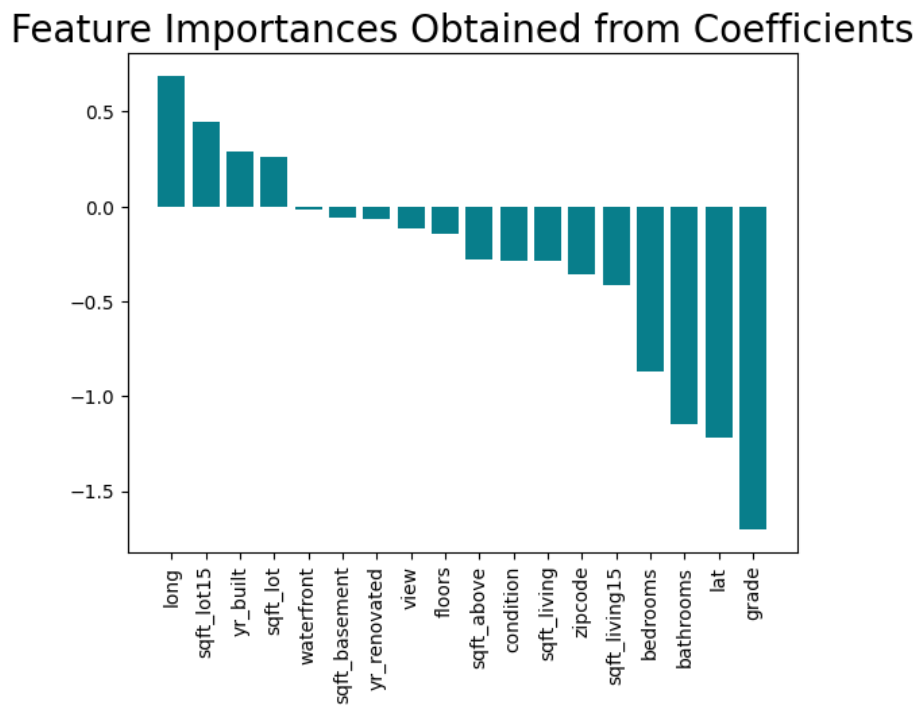

In [14]:
# Train a random forest to get the importance of features to the target'
#Time coplexity= approx 31 sec to 50 sec

# Drop the target and non-relevant columns
#assign the target to y 'we want to see the importance of features to the target'
df_importance=df.copy()
X = df_importance=df.copy().drop(columns=['id','price','date','year_built_group'] , errors='ignore')  # ignoring the error if the columns already dropped ,'year_built_group' IS ADDED AFTER TO DF FOR ANALYSIS IT DOES CAUSE A TROUBLE IF WE DONT DROP IT HERE IN CASE RE-RUN THE CODE
y = df_importance=df.copy()['price']

# Train a Random Forest Regressor
model = RandomForestRegressor()
model.fit(X, y)

# Get feature importances
importances = model.feature_importances_

# Create feature_importances DataFrame for better visualization
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

print(feature_importances)



          Feature  Importance
8           grade    0.325766
2     sqft_living    0.262157
14            lat    0.161887
15           long    0.069301
16  sqft_living15    0.031629
5      waterfront    0.031232
11       yr_built    0.025809
9      sqft_above    0.019465
3        sqft_lot    0.013679
13        zipcode    0.013290
17     sqft_lot15    0.013114
6            view    0.010479
1       bathrooms    0.007277
10  sqft_basement    0.005316
7       condition    0.002925
0        bedrooms    0.002823
4          floors    0.001993
12   yr_renovated    0.001859


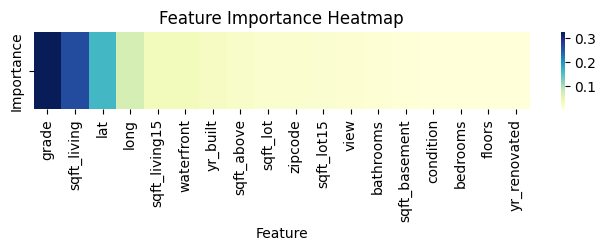

In [15]:
# Plot feature importances as a heatmap
plt.figure(figsize=(8, 1))
sns.heatmap(feature_importances.set_index('Feature').T, cmap='YlGnBu')
plt.title('Feature Importance Heatmap')
plt.show()


In [16]:
# Drop non-numerical columns like 'date'
df_numeric = df.select_dtypes(include=[float, int])

# Calculate the correlation matrix
corr_matrix = df_numeric.corr()
corr_matrix

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.016762,0.001240,0.005158,-0.012259,-0.132109,0.018524,-0.002721,0.011592,-0.023784,0.008130,-0.010843,-0.005152,0.021379,-0.016907,-0.008221,-0.001891,0.020798,-0.002903,-0.138798
price,-0.016762,1.000000,0.308377,0.525136,0.702035,0.089661,0.256793,0.266370,0.397294,0.036361,0.667434,0.605567,0.323816,0.054011,0.126434,-0.053201,0.307003,0.021626,0.585378,0.082447
bedrooms,0.001240,0.308377,1.000000,0.515932,0.576693,0.031713,0.175466,-0.006578,0.079543,0.028502,0.356978,0.477614,0.303112,0.154198,0.018850,-0.152754,-0.008913,0.129482,0.391666,0.029256
bathrooms,0.005158,0.525136,0.515932,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,-0.012259,0.702035,0.576693,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,-0.132109,0.089661,0.031713,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.018524,0.256793,0.175466,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.002721,0.266370,-0.006578,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.011592,0.397294,0.079543,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,-0.023784,0.036361,0.028502,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406



***Key Observations:***



**"Strong Correlations with Price"**



sqft_living: This feature has a high positive correlation with price (0.702035),
 indicating that larger living areas tend to be more expensive.

grade: Also shows a strong positive correlation with price (0.667434),
 meaning homes with higher quality and finishes are typically more expensive.

sqft_above: Has a significant positive correlation with price (0.605567),
 likely because it directly affects the overall size of the house.

bathrooms: Correlates strongly with price (0.525136),
 indicating that more bathrooms generally lead to higher property prices.



 **Moderate Correlations:**

view and waterfront: Both features have moderate positive correlations with price (0.397294 and 0.266370, respectively). These indicate that properties with better views and waterfront locations are valued higher.

sqft_living15: This represents the living area of nearby homes, and its correlation with price (0.585378) suggests that homes in neighborhoods with larger homes tend to be more expensive.


**Low or Negative Correlations:**

zipcode: Shows a slight negative correlation with price (-0.053201), suggesting
 that in this dataset, the zip code does not strongly predict the price.

yr_built and condition: These features have very low correlations with price,
 which may indicate that the age and general condition of the property are less
  predictive of price compared to other features.

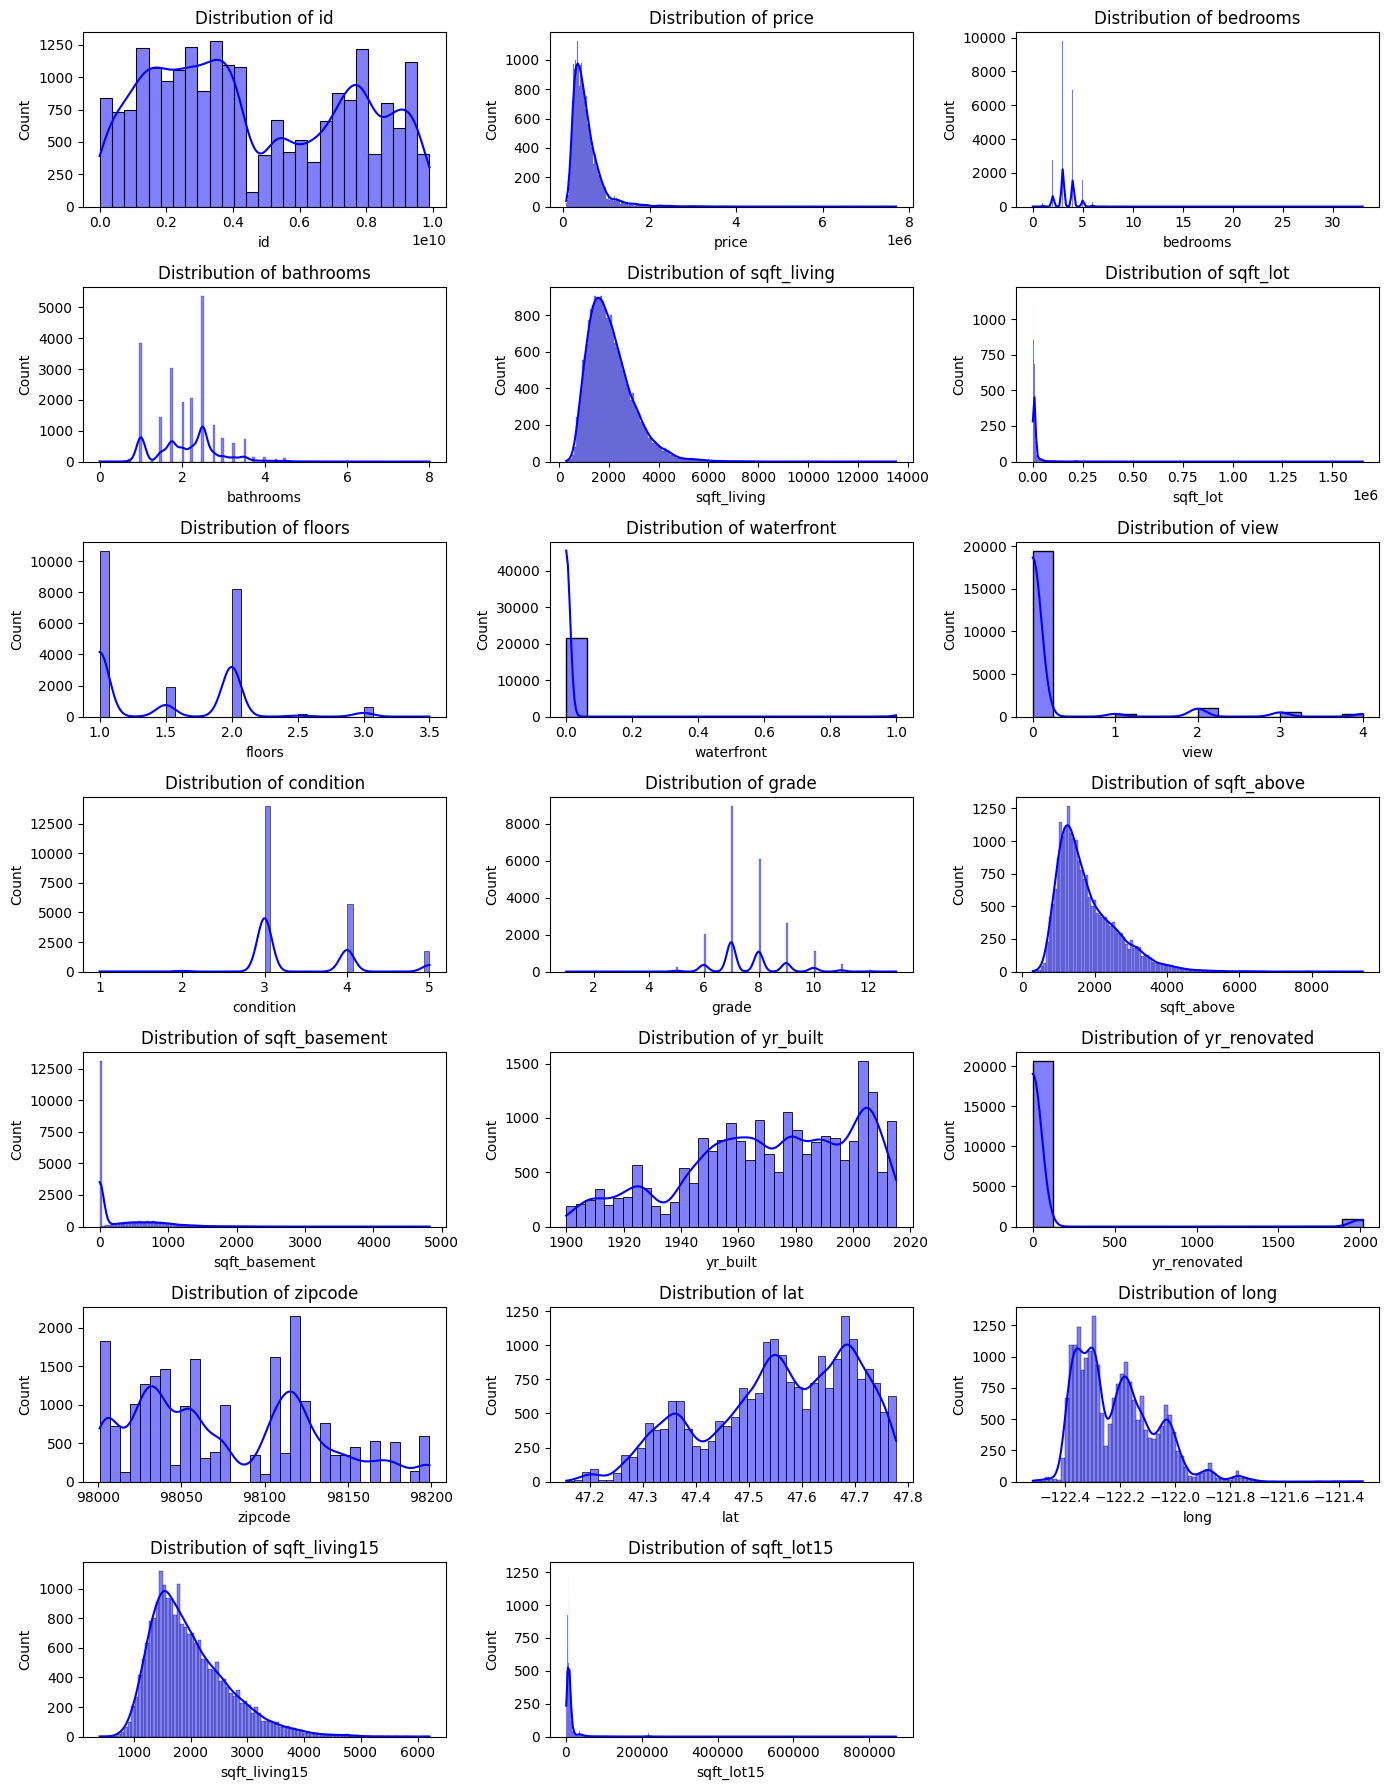

In [17]:
#the distribution of all features( histogram plot)
# Selecting only numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plotting distributions
plt.figure(figsize=(14,18))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i + 1)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


**Price:** The actual distribution of selling price is highly right-skewed, with most houses falling in the low price range and only a few very high-priced outliers.


**Bedrooms:** Most homes lie in the range from 2 to 6 bedrooms, even though there are extreme cases of more than 10 bedrooms in a house.


**Bathrooms:** For the most part, the number of bathrooms within a home ranges from 1 to 3, though very few are over 4.


**Square Foot Living:** The majority of the houses have their living areas falling in between 1000 to 3000 square feet, which for the majority of the houses is the bench mark size.


**Square Foot Lot:** Distribution of lot size is very positively skewed , the majority of the houses have smaller lots while a few of them have lots that are extremely huge in size.


**Floors:** Most houses either contain 1 or 2 floors; a few have 3. An extremely small number have more than 3 floors.


**Waterfront:** A slim majority of houses do not sit on waterfront property-most indeed sit land-locked-with a small handful of homes on the waterfront.


**View:** Most houses have zero view rating; only a handful of homes have view ratings in the range between 1 and 4.


**Condition:** Most of the properties are rated around a 3 in the condition scale, meaning an average rating; very few homes rated in poor or excellent condition.


**Grade:** Grade distribution is skewed, with most homes rated between 6 to 9, indicating that most of the homes lie in the average to above-average construction quality.


**Square Foot Above (sqft_above):** Much like sqft_living, most homes have above ground square footage from 1000 to 3000 square feet.


**Square Foot Basement (sqft_basement):** This distribution suggests that most houses do not have basements, or they are very small. There are some rather large basement areas for a few houses.


**Year Built (yr_built):** House development indeed gradually improved over time, peaking in the 1950s and into the 1970s. It consists of less number of houses beyond the year 2000.


**Year Renovated (yr_renovated):** Most houses have never been renovated, but there is some renovations between the year 1950 and 2000. Very few recent renovations.


**Zipcode:** Houses are from a wide range in terms of zip codes. This means that location will play an important role in pricing and analysis.


**Lat:** most of the houses come within the same range of latitude values, hence lie within the same geographic boundary. Long: it is also the case with longitudes as they are coming along within a very short range, further suggesting the geographic limits of the data.


**Square Foot Living in Last 15 Years:** This feature is similar to sqft_living. The surface area of living in the last 15 years - or of the properties nearby - is right-skewed because most of the houses are around 1000 to 3000 square feet.


**Square Foot Lot15:** This feature is similar to sqft_lot. It is right-skewed, showing that most of the homes are on smaller lots while a few are on larger lots.

In [18]:
#Display a dataframe that contain number of outliers and unique values for each column
# and the percentage of each
#Calculating outliers by a function
def find_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return outliers

# Creating lists for unique value counts and number of outliers
unique_counts = []
outlier_counts = []

# Total number of records
total_records = len(df)

# Calculating unique counts and outlier counts for each numerical column
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    unique_counts.append(len(df[col].unique()))
    outliers = find_outliers(df[col])
    outlier_counts.append(len(outliers))

# Creating a DataFrame to store the results
result_df = pd.DataFrame({
    'Column Name': df.select_dtypes(include=['int64', 'float64']).columns,
    'Unique Values Count': unique_counts,
    'Number of Outliers': outlier_counts ,
    'unique values percentage': [(uc / total_records) * 100 for uc in unique_counts],
    'outliers percentage': [(oc / total_records) * 100 for oc in outlier_counts]
})

# Displaying the resulting table
result_df



,Column Name,Unique Values Count,Number of Outliers,unique values percentage,outliers percentage
0,id,21436,0,99.181048,0.000000
1,price,4029,1146,18.641558,5.302364
2,bedrooms,13,546,0.060149,2.526257
3,bathrooms,30,571,0.138805,2.641928
4,sqft_living,1038,572,4.802665,2.646555
5,sqft_lot,9782,2425,45.259797,11.220099
6,floors,6,0,0.027761,0.000000
7,waterfront,2,163,0.009254,0.754176
8,view,5,2124,0.023134,9.827419
9,condition,5,30,0.023134,0.138805


#What is the average price of properties listed in each zip code?

In [19]:
ZipUniqueValues=df['zipcode'].unique()
ZipUniqueValues

array([98178, 98125, 98028, 98136, 98074, 98053, 98003, 98198, 98146,
       98038, 98007, 98115, 98107, 98126, 98019, 98103, 98002, 98133,
       98040, 98092, 98030, 98119, 98112, 98052, 98027, 98117, 98058,
       98001, 98056, 98166, 98023, 98070, 98148, 98105, 98042, 98008,
       98059, 98122, 98144, 98004, 98005, 98034, 98075, 98116, 98010,
       98118, 98199, 98032, 98045, 98102, 98077, 98108, 98168, 98177,
       98065, 98029, 98006, 98109, 98022, 98033, 98155, 98024, 98011,
       98031, 98106, 98072, 98188, 98014, 98055, 98039])

In [20]:
len(ZipUniqueValues)

70

In [21]:
# Get the unique zip codes from the dataframe
ZipUniqueValues = df['zipcode'].unique()

# Initialize dictionaries to store average prices and record counts
average_prices = {}
count_records = {}

for zipcode in ZipUniqueValues:
    # Filter the dataframe for the current zipcode
    zip_data = df[df['zipcode'] == zipcode]

    # Calculate the average price for this zipcode
    avg_price = zip_data['price'].mean()

    # Calculate the count of records for this zipcode
    count = zip_data.shape[0]

    # Store the result in the dictionary
    average_prices[zipcode] = avg_price
    count_records[zipcode] = count

# Convert the dictionary to a DataFrame for easier viewing
average_prices_df = pd.DataFrame(list(average_prices.items()), columns=['Zipcode', 'Average Price'])
average_prices_df['Record Count'] = average_prices_df['Zipcode'].map(count_records)

# Format the 'Average Price' column to be more human-readable
average_prices_df['Average Price'] = average_prices_df['Average Price'].apply(lambda x: f"${x:,.2f}")

# Temporarily set pandas to display all rows
pd.set_option('display.max_rows', None)
df = df.drop(columns=['id'], errors='ignore')

# Print the DataFrame sorted by 'Average Price'
print(average_prices_df.sort_values(by='Average Price', ascending=False))

# Reset display option to default
pd.reset_option('display.max_rows')


    Zipcode  Average Price  Record Count
49    98102    $901,258.27           105
57    98109    $879,623.62           109
33    98105    $862,825.23           229
56    98006    $859,684.78           498
21    98119    $849,448.02           184
40    98005    $810,164.88           168
59    98033    $803,719.52           432
46    98199    $791,820.81           317
42    98075    $790,576.65           359
4     98074    $685,605.78           441
50    98077    $682,774.88           198
5     98053    $678,163.06           405
53    98177    $676,185.39           255
35    98008    $645,507.38           283
23    98052    $645,231.46           574
37    98122    $634,360.18           290
11    98115    $619,900.55           583
43    98116    $618,634.17           330
10    98007    $617,105.09           141
24    98027    $616,990.59           412
55    98029    $612,653.61           321
38    98144    $594,547.65           343
15    98103    $584,919.21           602
61    98024    $

In [22]:
 #another way
pd.set_option('display.max_rows', None)    # this line and the last line to display all rows

sort=df.groupby('zipcode')['price'].mean().apply(lambda x: f"${x:,.2f}")
print(sort.sort_values(ascending=False))

pd.reset_option('display.max_rows')

zipcode
98102      $901,258.27
98109      $879,623.62
98105      $862,825.23
98006      $859,684.78
98119      $849,448.02
98005      $810,164.88
98033      $803,719.52
98199      $791,820.81
98075      $790,576.65
98074      $685,605.78
98077      $682,774.88
98053      $678,163.06
98177      $676,185.39
98008      $645,507.38
98052      $645,231.46
98122      $634,360.18
98115      $619,900.55
98116      $618,634.17
98007      $617,105.09
98027      $616,990.59
98029      $612,653.61
98144      $594,547.65
98103      $584,919.21
98024      $580,526.79
98107      $579,053.42
98117      $576,795.01
98072      $569,958.47
98136      $551,688.67
98065      $527,961.20
98034      $521,652.86
98059      $493,552.53
98011      $490,351.47
98070      $487,479.63
98125      $469,455.77
98166      $464,231.84
98028      $462,480.04
98014      $455,617.11
98045      $439,471.08
98019      $424,788.75
98126      $424,706.36
98155      $423,725.70
98010      $423,665.99
98056      $420,890.55
981

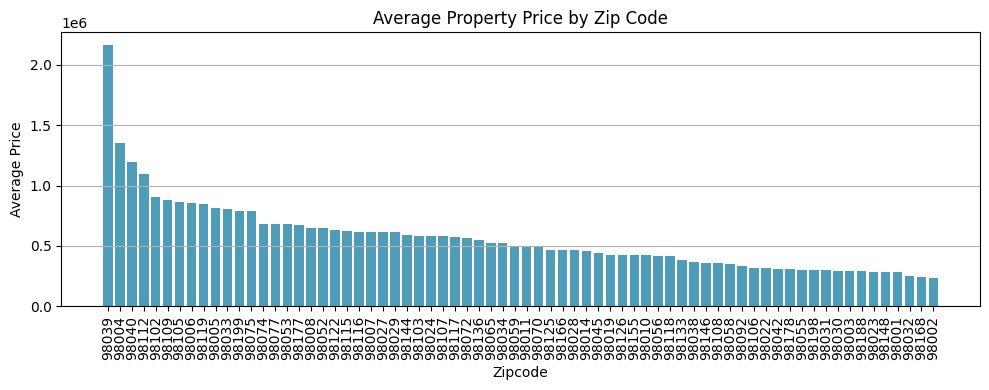

In [23]:
# Remove dollar signs and commas, then convert to float
average_prices_df['Average Price'] = average_prices_df['Average Price'].replace({'\$': '', ',': ''}, regex=True).astype(float)

# Now sort by 'Average Price'
average_prices_dff = average_prices_df.sort_values(by='Average Price', ascending=False)

# Create the bar plot
plt.figure(figsize=(10,4))
plt.bar(average_prices_dff['Zipcode'].astype(str), average_prices_dff['Average Price'], color='#4f9cb9')

# Add labels and title
plt.xlabel('Zipcode')
plt.ylabel('Average Price')
plt.title('Average Property Price by Zip Code')
plt.xticks(rotation=90)  # Rotate x labels for better readability
plt.grid(True, which='major', axis='y')  # Add gridlines on the y-axis
plt.tight_layout()

# Show the plot
plt.show()


98039 zip code have the highest avg price  $2,160,606.60  and there is  50 homes within this zipcode

#How does the number of bedrooms affect the average price?

In [24]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [25]:
print(df['bedrooms'].unique())
print('number of unique values : ',len(df['bedrooms'].unique()))

[ 2  3  4  5  1  6  7  0  8  9 11 10 33]
number of unique values :  13


In [26]:
#how many record we have from each unique number of bedrooms
for i in df['bedrooms'].unique():
  print(i ,"  ", len(df[df['bedrooms']==i]))

2    2761
3    9823
4    6882
5    1601
1    199
6    272
7    38
0    13
8    13
9    6
11    1
10    3
33    1


In [27]:
# Group the data by the number of bedrooms and calculate the average price
bedroom_price_df = df.groupby('bedrooms')['price'].mean().reset_index()

# Rename columns for clarity
bedroom_price_df.columns = ['Number of Bedrooms', 'Average Price']

# Sort by the number of bedrooms
bedroom_price_df = bedroom_price_df.sort_values(by='Number of Bedrooms')

# Format the Average Price column
bedroom_price_df['Average Price'] = bedroom_price_df['Average Price'].apply(lambda x: f"${x:,.2f}")

bedroom_price_df['records count'] = bedroom_price_df['Number of Bedrooms'].apply(lambda x: len(df[df['bedrooms']==x]))

bedroom_price_df

display(bedroom_price_df.style.hide(axis="index"))

Number of Bedrooms,Average Price,records count
0,"$409,503.85",13
1,"$317,642.88",199
2,"$401,311.08",2761
3,"$466,256.95",9823
4,"$635,419.50",6882
5,"$786,599.83",1601
6,"$825,520.64",272
7,"$951,184.66",38
8,"$1,105,076.92",13
9,"$893,999.83",6


# Notes according to what we see in the table
1- zero bedrooms have an average price of $409,503.85, which is relatively high compared to one and two bedroom homes. maybe they are studios or a noisy records . the higher price suggest that other factors like size and home location might effect the prices of these homes.


```

```
2- in general homes prices attend to increase linearly whenever the # of bedroom increase from 1 to 8 bedrooms. then the price decrease when the # of bedrooms are 9,10,11,33 . though the records of such rooms are so few .maybe they are outliers or features another than bedroom number effect them


```
```
3- maybe people prefer # of bedroom less than 9. that is why their are not many homes (records) for such homes .



```

```
4- homes with 3 and 4 bedrooms have the most records . they seem to be more prefered by people. and which show in someway the average number of families members nowadays.


```
```

5- 11 and 13 bedrooms homes have only one record they might be outliers as we point before.

```

```






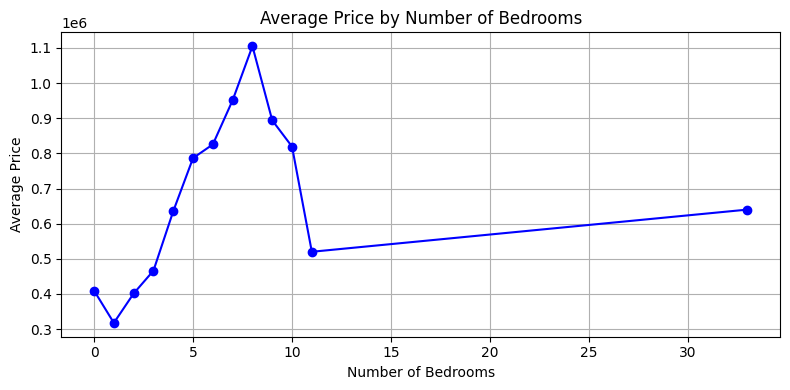

In [28]:
# Group the data by the number of bedrooms and calculate the average price
bedroom_price_df = df.groupby('bedrooms')['price'].mean().reset_index()

# Rename columns for clarity
bedroom_price_df.columns = ['Number of Bedrooms', 'Average Price']

# Sort by the number of bedrooms
bedroom_price_df = bedroom_price_df.sort_values(by='Number of Bedrooms')

# Plot the relationship between number of bedrooms and average price
plt.figure(figsize=(8, 4))
plt.plot(bedroom_price_df['Number of Bedrooms'], bedroom_price_df['Average Price'], marker='o', color='b')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Average Price')
plt.title('Average Price by Number of Bedrooms')
plt.grid(True)
plt.tight_layout()
plt.show()


**The average price in the plot linearly increase ffrom 1 bedroom to 8 then decrease for some reasons**

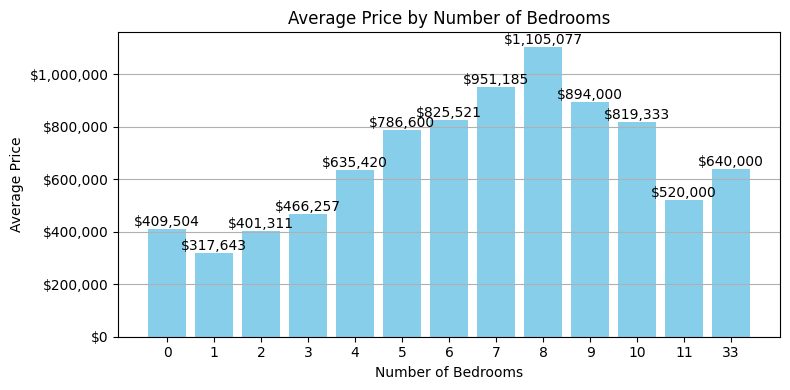

In [29]:
# Plot a bar chart
plt.figure(figsize=(8,4))
bars = plt.bar(bedroom_price_df['Number of Bedrooms'].astype(str), bedroom_price_df['Average Price'], color='skyblue')

# Format the y-axis with commas
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}'))

# Add labels on top of each bar to show the exact average price
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f'${yval:,.0f}', ha='center', va='bottom')

plt.xlabel('Number of Bedrooms')
plt.ylabel('Average Price')
plt.title('Average Price by Number of Bedrooms')
plt.grid(True, which='both', axis='y')  # Add grid for y-axis
plt.tight_layout()
plt.show()



why 9 10 11 33 avg price are less than 8 7 bedroom ?and why zero bedroom home price higher than 1 and 2

In [30]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

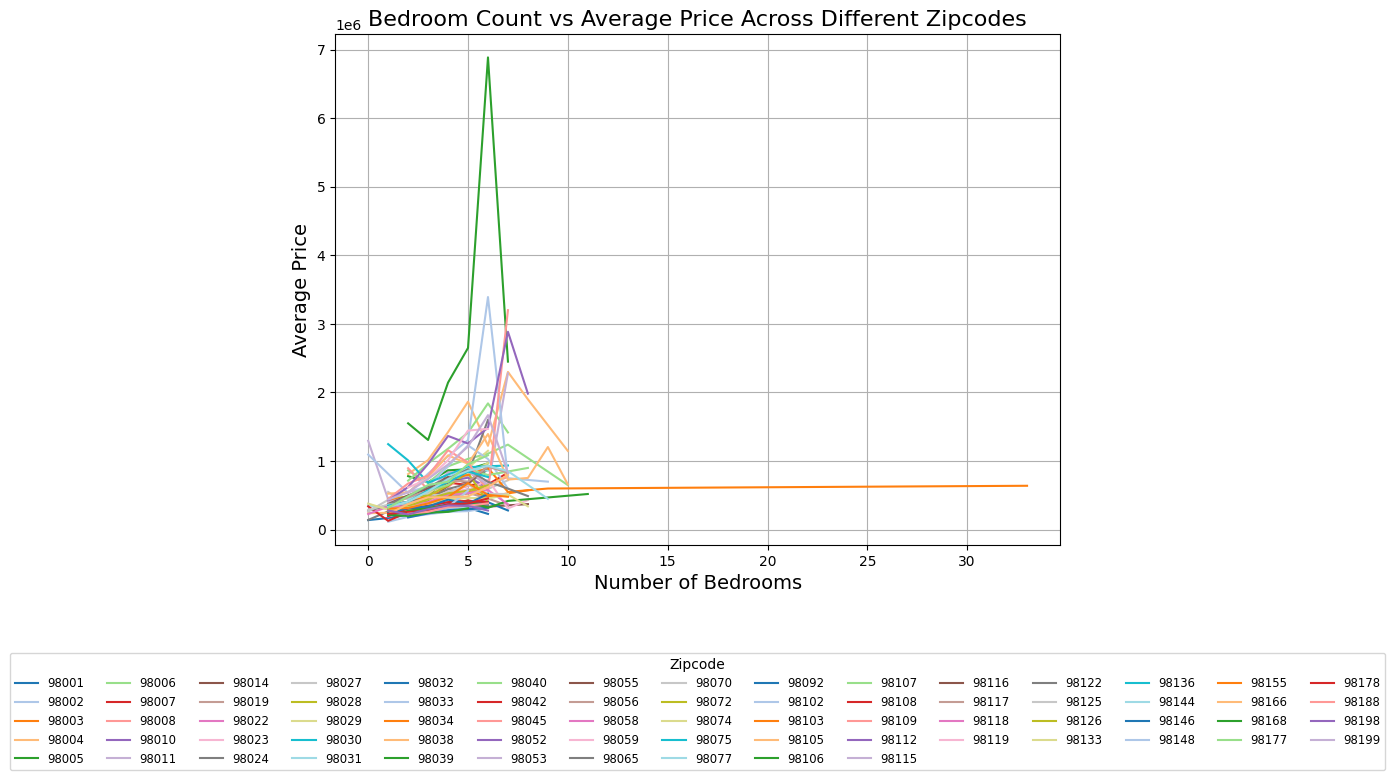

In [31]:
# Group by zipcode and bedrooms, then calculate the average price
location_bedroom_price = df.groupby(['zipcode', 'bedrooms']).agg({'price': 'mean'}).reset_index()

# Plot the correlation between bedroom count and price for different zip codes
plt.figure(figsize=(12, 8))
sns.lineplot(x='bedrooms', y='price', hue='zipcode', data=location_bedroom_price, palette='tab20')
plt.title('Bedroom Count vs Average Price Across Different Zipcodes', fontsize=16)
plt.xlabel('Number of Bedrooms', fontsize=14)
plt.ylabel('Average Price', fontsize=14)
plt.legend(title='Zipcode',  bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=15, fontsize='small')  # Adjust ncol for horizontal layout
plt.subplots_adjust(top=0.9, bottom=0.2)  # Adjust 'bottom' to move plot down
plt.grid(True)
plt.tight_layout()
plt.show()


In [32]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

#Are properties with a waterfront view significantly more expensive than those without?

In [33]:
# Group the data by the 'waterfront' column and calculate the average price
waterfront_price_df = df.groupby('waterfront')['price'].mean().reset_index()

# Rename columns for clarity
waterfront_price_df.columns = ['Waterfront', 'Average Price']

# Format the Average Price for better readability
waterfront_price_df['Average Price'] = waterfront_price_df['Average Price'].apply(lambda x: f"${x:,.2f}")

# Display the result
waterfront_price_df


,Waterfront,Average Price
0,0,"$531,564.04"
1,1,"$1,661,876.02"


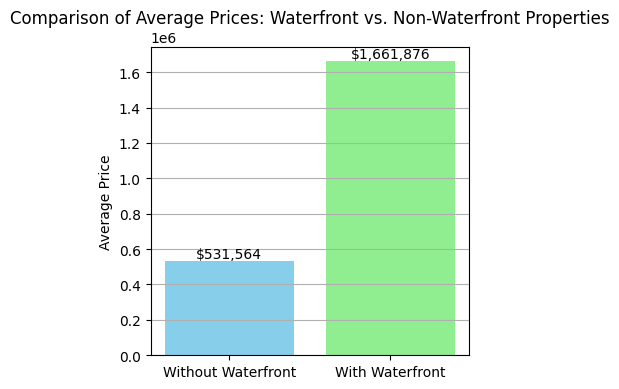

In [34]:
# Plot a bar chart comparing waterfront vs non-waterfront properties
plt.figure(figsize=(4, 4))
bars = plt.bar(['Without Waterfront', 'With Waterfront'], df.groupby('waterfront')['price'].mean(), color=['skyblue', 'lightgreen'])

# Add labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f'${yval:,.0f}', ha='center', va='bottom')

plt.ylabel('Average Price')
plt.title('Comparison of Average Prices: Waterfront vs. Non-Waterfront Properties')
plt.grid(True, which='both', axis='y')
plt.tight_layout()
plt.show()


homes with waterfront are 2 times higher in price from those with not

#Examine the relationship between the size of the living area ( sqft_living )and the price.

In [35]:
# Calculate the Pearson correlation coefficient
correlation = df['sqft_living'].corr(df['price'])
print(f"Pearson Correlation between Living Area and Price: {correlation:.2f}")


Pearson Correlation between Living Area and Price: 0.70


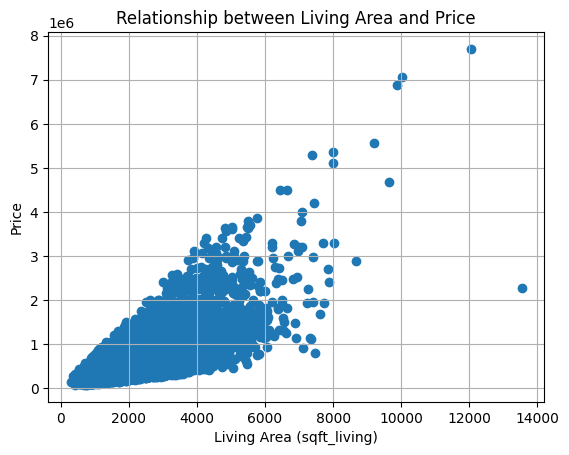

In [36]:
"""Correlation Test
A correlation test is another method to determine the
presence and extent of a linear relationship between two
quantitative variables. In our case, we would like to
statistically test whether there is a correlation between
the applicant’s investment and their work experience.
The first step is to visualize the relationship with a scatter plot,
 which is done using the line of code below.
 ref: https://www.pluralsight.com/resources/blog/guides/finding-relationships-data-with-python"""


plt.scatter(df['sqft_living'], df['price'])
plt.xlabel('Living Area (sqft_living)')
plt.ylabel('Price')
plt.title('Relationship between Living Area and Price')
plt.grid(True)
plt.show()

In [37]:
# Group the data by the the size of the living area
sqft_living_price_df = df.groupby('sqft_living')['price'].mean().reset_index()

# Rename columns for clarity
sqft_living_price_df.columns = ['living area size', 'Average Price']
sqft_living_price_df['Average Price'] = sqft_living_price_df['Average Price'].apply(lambda x: f"${x:,.2f}")
sqft_living_price_df

,living area size,Average Price
0,290,"$142,000.00"
1,370,"$276,000.00"
2,380,"$245,000.00"
3,384,"$265,000.00"
4,390,"$236,500.00"
...,...,...
1033,9640,"$4,668,000.00"
1034,9890,"$6,885,000.00"
1035,10040,"$7,062,500.00"
1036,12050,"$7,700,000.00"


The price increases whenever the size of the living area size increase

#How does the condition ( condition ) influence the property price?

In [38]:
corr_condition_price = df['condition'].corr(df['price'])
print(f"Pearson Correlation between Condition and Price: {corr_condition_price:.2f}")

Pearson Correlation between Condition and Price: 0.04


#Are newer properties in the feature year built( yr_built ) priced differently compared to older ones?

In [39]:
print("the yr_built feature is the 7th important feature as we calculate the importance using random forest")
print()
print("the correlation with the price for yr_built = ", df['yr_built'].corr(df['price']))

the yr_built feature is the 7th important feature as we calculate the importance using random forest

the correlation with the price for yr_built =  0.054010940596575345


In [40]:
df["yr_built"].describe()  # to get min and max values

,yr_built
count,21613.000000
mean,1971.005136
std,29.373411
min,1900.000000
25%,1951.000000
50%,1975.000000
75%,1997.000000
max,2015.000000


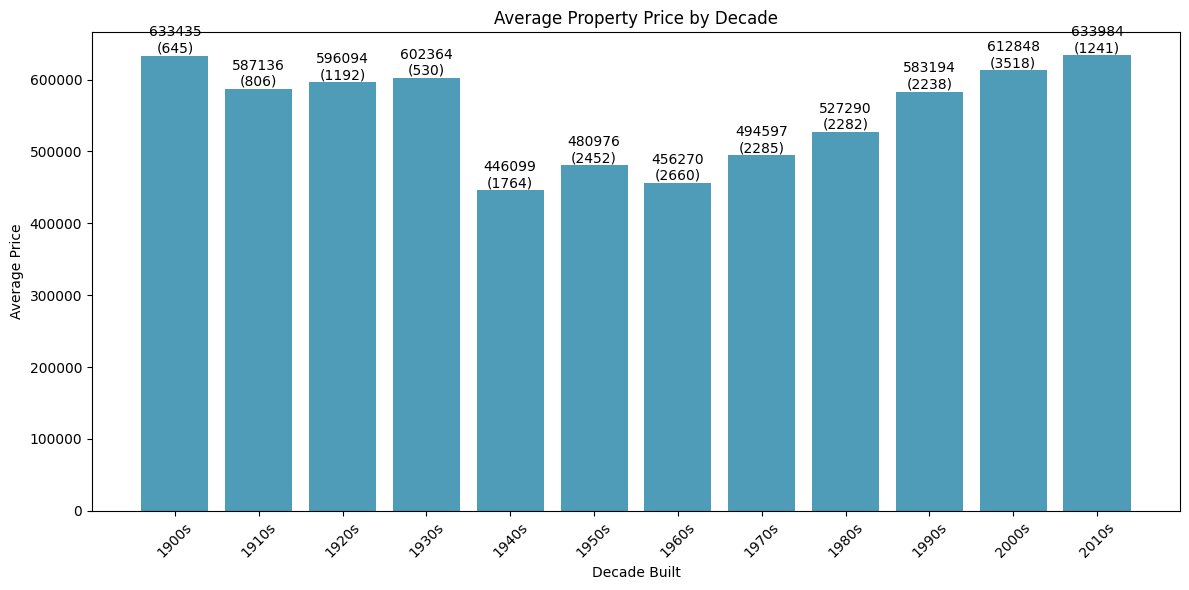

how home prices vary across different time periods


In [41]:
# grouping year built feature by decades

# Create 10-year intervals (bins) for yr_built
bins = list(range(1900, 2021, 10))  # From 1900 to 2020, in intervals of 10 years
labels = [f"{year}s" for year in bins[:-1]]  # Create labels like "1900s", "1910s", etc.

# Assign each home to its respective decade
df['year_built_group'] = pd.cut(df['yr_built'], bins=bins, labels=labels, right=False)


# Calculate average price and count records for each decade
decade_stats = df.groupby('year_built_group', observed=True).agg(
    avg_price=('price', 'mean'),
    record_count=('price', 'count')
).reset_index()

# Plot the average price by decade with values on top of the bars
plt.figure(figsize=(12, 6))
bars = plt.bar(decade_stats['year_built_group'], decade_stats['avg_price'], color='#4f9cb9')

# Add the average prices and record count on top of the bars
for bar, count in zip(bars, decade_stats['record_count']):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.0f}\n({count})', ha='center', va='bottom')

plt.xlabel('Decade Built')
plt.ylabel('Average Price')
plt.title('Average Property Price by Decade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("how home prices vary across different time periods")

In [42]:
# Calculate average price, record count, average sqft_living, price_per_sqft for each decade
decade_stats = df.groupby('year_built_group', observed=True).agg(
    record_count=('price', 'count'),
    avg_price=('price', 'mean'),
    avg_sqft_living=('sqft_living', 'mean')
    # Remove avg_price_per_sqft - This column does not exist yet!
).reset_index()

# Display the new DataFrame with all the requested information
decade_stats

,year_built_group,record_count,avg_price,avg_sqft_living
0,1900s,645,633434.858915,1790.683721
1,1910s,806,587135.682382,1764.547146
2,1920s,1192,596094.193792,1753.346477
3,1930s,530,602364.441509,1825.230189
4,1940s,1764,446098.777778,1507.807256
5,1950s,2452,480975.618271,1749.661501
6,1960s,2660,456269.535714,1930.680075
7,1970s,2285,494596.606565,2137.200875
8,1980s,2282,527290.176599,2195.521472
9,1990s,2238,583194.011171,2492.585791


 ***Newer properties tend to have a slightly higher total price but are significantly larger.
On a per-square-foot basis, older properties are priced higher than newer ones.***

In [43]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'year_built_group'],
      dtype='object')

In [44]:
feature_importances

,Feature,Importance
8,grade,0.325766
2,sqft_living,0.262157
14,lat,0.161887
15,long,0.069301
16,sqft_living15,0.031629
5,waterfront,0.031232
11,yr_built,0.025809
9,sqft_above,0.019465
3,sqft_lot,0.013679
13,zipcode,0.013290


#Is there a noticeable difference in prices between properties with and without a basement ( sqft_basement )?

In [45]:
# Group the properties by whether they have a basement or not
df['has_basement'] = df['sqft_basement'] > 0

# Calculate the average price for properties with and without basements
basement_price_stats = df.groupby('has_basement')['price'].agg(
    avg_price=('mean'),
    record_count=('count')
).reset_index()

# Replace the boolean values with readable labels
basement_price_stats['has_basement'] = basement_price_stats['has_basement'].replace({True: 'With Basement', False: 'Without Basement'})

# Display the results
print(basement_price_stats)


       has_basement      avg_price  record_count
0  Without Basement  486884.806643         13126
1     With Basement  622373.563803          8487


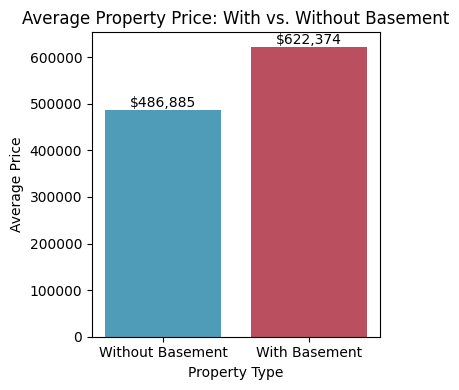

In [46]:
# Plot the average price for properties with and without basements
plt.figure(figsize=(4,4))
plt.bar(basement_price_stats['has_basement'], basement_price_stats['avg_price'], color=['#4f9cb9', '#b94f5f'])
plt.xlabel('Property Type')
plt.ylabel('Average Price')
plt.title('Average Property Price: With vs. Without Basement')

# Add price labels on top of each bar
for i, value in enumerate(basement_price_stats['avg_price']):
    plt.text(i, value, f"${value:,.0f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

622374 - 486885 =135489
homes with basement are higher 135489 on average

#Analyze if properties in areas with larger sqft_lot15 have higher average prices.

In [47]:
df["sqft_lot15"].describe()

,sqft_lot15
count,21613.000000
mean,12768.455652
std,27304.179631
min,651.000000
25%,5100.000000
50%,7620.000000
75%,10083.000000
max,871200.000000


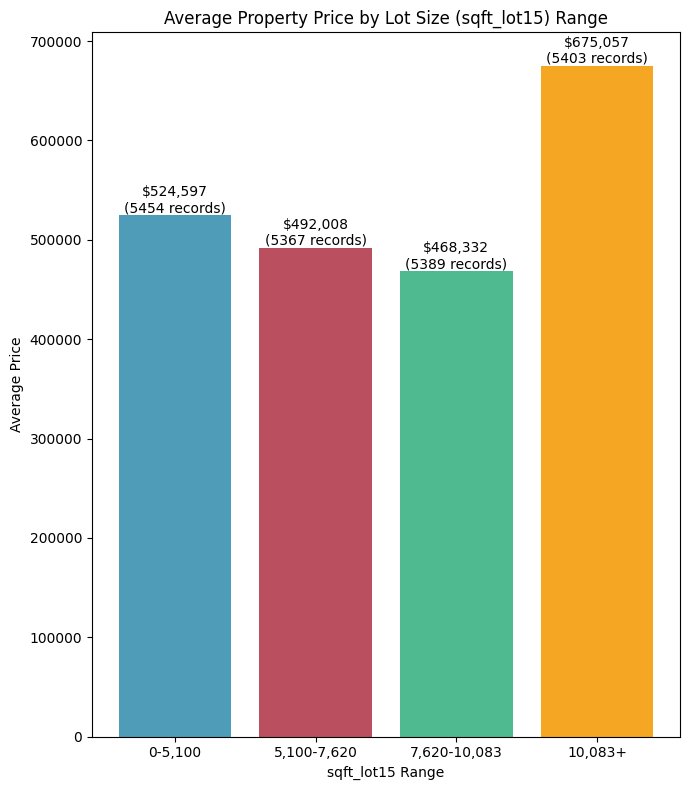

In [48]:
# Define bins based on percentiles and max value
bins = [0, 5100, 7620, 10083, df['sqft_lot15'].max()]  # Using the provided percentiles and max value
labels = ['0-5,100', '5,100-7,620', '7,620-10,083', '10,083+']

# Assign each property to a bin based on sqft_lot15
df['sqft_lot15_group'] = pd.cut(df['sqft_lot15'], bins=bins, labels=labels)

# Calculate the average price and record count for each bin
sqft_lot15_price_stats = df.groupby('sqft_lot15_group', observed=True).agg(
    avg_price=('price', 'mean'),
    record_count=('price', 'count')
).reset_index()

# Define a list of colors for the bars
colors = ['#4f9cb9', '#b94f5f', '#4fb98f', '#f5a623']

# Plot the average price by sqft_lot15 range
plt.figure(figsize=(7,8))
bars = plt.bar(sqft_lot15_price_stats['sqft_lot15_group'], sqft_lot15_price_stats['avg_price'], color=colors)

# Add the average price and record count on top of the bars
for bar, avg_price, record_count in zip(bars, sqft_lot15_price_stats['avg_price'], sqft_lot15_price_stats['record_count']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"${avg_price:,.0f}\n({record_count} records)",
             ha='center', va='bottom')

# Add labels and title
plt.xlabel('sqft_lot15 Range')
plt.ylabel('Average Price')
plt.title('Average Property Price by Lot Size (sqft_lot15) Range')

# Show the plot
plt.tight_layout()
plt.show()


In [49]:
# Group by both zipcode and sqft_lot15_group with observed=True to avoid the FutureWarning
price_by_lot_and_zip = df.groupby(['zipcode', 'sqft_lot15_group'], observed=True).agg(
    avg_price=('price', 'mean'),
    record_count=('price', 'count')
).reset_index()

# Sort the result by avg_price in ascending order
price_by_lot_and_zip = price_by_lot_and_zip.sort_values(by='avg_price', ascending=True)

# Set pandas option to display all rows
pd.set_option('display.max_rows', None)

# Display the sorted result
print(price_by_lot_and_zip)

# Reset the option back to default after displaying
pd.reset_option('display.max_rows')


     zipcode sqft_lot15_group     avg_price  record_count
39     98014          0-5,100  1.470000e+05             2
78     98032          0-5,100  1.593230e+05             5
51     98023          0-5,100  2.182259e+05             9
243    98168      5,100-7,620  2.184578e+05            67
5      98002      5,100-7,620  2.224638e+05            69
6      98002     7,620-10,083  2.290825e+05            55
48     98022      5,100-7,620  2.331930e+05            30
8      98003          0-5,100  2.348535e+05             8
7      98002          10,083+  2.407601e+05            30
244    98168     7,620-10,083  2.446560e+05           108
79     98032      5,100-7,620  2.448493e+05            31
242    98168          0-5,100  2.473333e+05             3
245    98168          10,083+  2.510638e+05            91
80     98032     7,620-10,083  2.510939e+05            68
47     98022          0-5,100  2.533754e+05             8
4      98002          0-5,100  2.544486e+05            45
2      98001  

Location (zipcode) plays a significant role in property prices, often more so than lot size. Even with similar lot sizes, properties in wealthier or more desirable zipcodes can be dramatically more expensive.
Lot size does have an impact, as larger lots tend to be associated with higher prices, but this is more pronounced in premium zip codes.
Affordable vs. Luxury Markets: The data shows a clear distinction between more affordable markets (like 98002, 98032) and high-end markets (like 98112, 98039).


areas with more land (larger lot sizes ) have a higher average price

```

```


Interestingly, properties with mid-sized lots (5,100-10,083 sq ft) have lower average prices compared to smaller lot sizes (0-5,100 sq ft). This could indicate that these mid-sized properties are in areas where lot size does not play a significant role in driving up prices.



```

```



#Investigate whether properties in certain geographic locations (based on lat and long ) are more expensive.

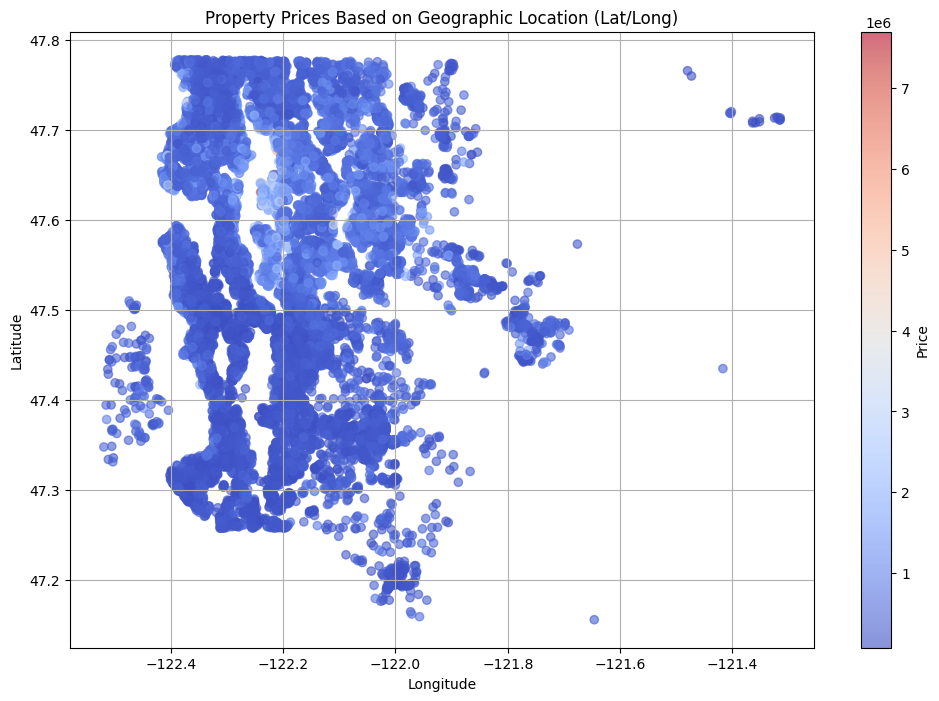

In [50]:

# Assuming df is your DataFrame and it contains 'lat', 'long', and 'price'

# Create a scatter plot of latitude and longitude, color-coded by price
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['long'], df['lat'], c=df['price'], cmap='coolwarm', alpha=0.6)

# Adding color bar to show the price scale
plt.colorbar(scatter, label='Price')

# Plot labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Property Prices Based on Geographic Location (Lat/Long)')
plt.grid(True)

plt.show()


The homes are heavily concentrated in a specific latitude and longitude range (around -122.4 to -122.0 for longitude and 47.3 to 47.8 for latitude). This suggests that most of the properties in the dataset are located within a particular geographic area, possibly representing a specific city or metropolitan region.

```

```
The color bar on the right indicates that the price scale ranges from approximately 1 million to 7 million dollars.



```
```
Most of the properties in this geographic cluster seem to be in the lower price range (darker blue), with fewer properties in the higher price range (red or light orange), meaning that properties in this area tend to be more affordable on average.


```

```


A few scattered points, mostly to the right and bottom right (in the more isolated areas), seem to be higher-priced properties. These are marked with lighter colors (indicating higher prices).



```
```
 It is clear that geographic location (latitude and longitude) has an impact on property prices. Properties in densely populated or central areas tend to have lower prices, while more isolated or exclusive areas seem to have higher-priced properties.




#Determine if properties with more floors ( floors ) tend to have higher or lower prices.

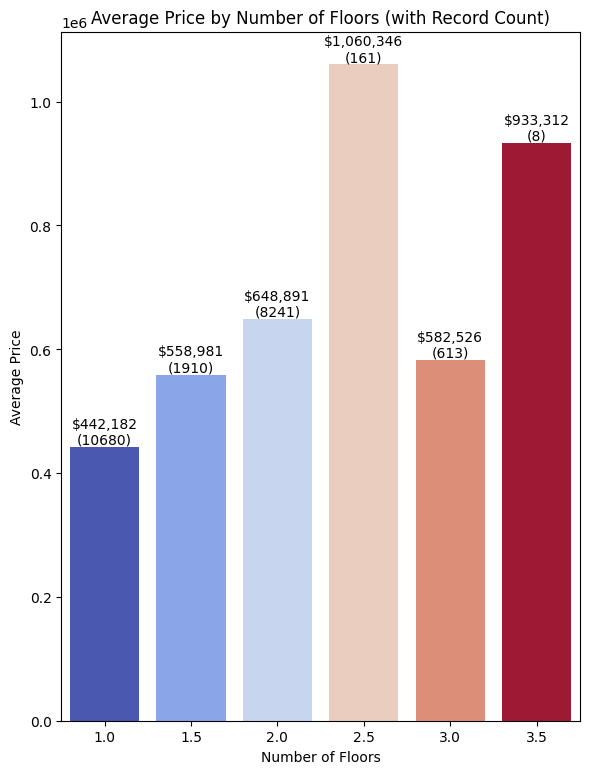

In [51]:
# Group by 'floors' and calculate the average price and count of records for each group
floor_price = df.groupby('floors').agg({'price': 'mean', 'floors': 'size'})
# Rename the 'floors' column to avoid conflict and reset the index
floor_price = floor_price.rename(columns={'floors': 'count'}).reset_index()
floor_price.columns = ['floors', 'avg_price', 'count']

# Create a bar plot to visualize the relationship, using 'floors' as hue and applying the 'coolwarm' palette
plt.figure(figsize=(6, 8))
bars = sns.barplot(x='floors', y='avg_price', hue='floors', data=floor_price, palette='coolwarm', legend=False)

# Add average price and count of records above each bar
for index, bar in enumerate(bars.patches):
    height = bar.get_height()  # Get height of the bar (average price)
    count = floor_price['count'].iloc[index]  # Get the count of records for the respective floor
    avg_price = floor_price['avg_price'].iloc[index]  # Get the average price
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'${avg_price:,.0f}\n({count})',
             ha='center', va='bottom')

# Add labels and title
plt.xlabel('Number of Floors')
plt.ylabel('Average Price')
plt.title('Average Price by Number of Floors (with Record Count)')

# Display the plot
plt.tight_layout()
plt.show()

In [52]:
pd.set_option('display.max_rows', None)
print(df['floors'].head(200))
pd.reset_option('display.max_rows')

0      1.0
1      2.0
2      1.0
3      1.0
4      1.0
5      1.0
6      2.0
7      1.0
8      1.0
9      2.0
10     1.0
11     1.0
12     1.5
13     1.0
14     1.5
15     2.0
16     2.0
17     1.5
18     1.0
19     1.0
20     1.0
21     1.0
22     2.0
23     1.0
24     2.0
25     1.5
26     2.0
27     1.5
28     1.0
29     2.0
30     2.0
31     3.0
32     1.5
33     1.5
34     1.0
35     1.5
36     1.0
37     2.0
38     1.0
39     2.0
40     2.0
41     1.0
42     2.0
43     2.0
44     1.0
45     2.0
46     1.0
47     2.0
48     1.0
49     1.0
50     1.0
51     1.0
52     1.0
53     1.0
54     1.5
55     2.0
56     2.0
57     2.0
58     2.0
59     2.0
60     1.0
61     1.0
62     2.0
63     3.0
64     1.0
65     1.5
66     2.0
67     2.0
68     1.0
69     1.0
70     1.0
71     1.0
72     1.5
73     2.0
74     1.0
75     2.0
76     1.0
77     1.0
78     1.0
79     2.0
80     2.0
81     2.0
82     1.0
83     1.0
84     1.0
85     2.0
86     1.5
87     2.0
88     2.0
89     2.0
90     2.0

floors value should be discrete not continuos like 1.5 and 2.5

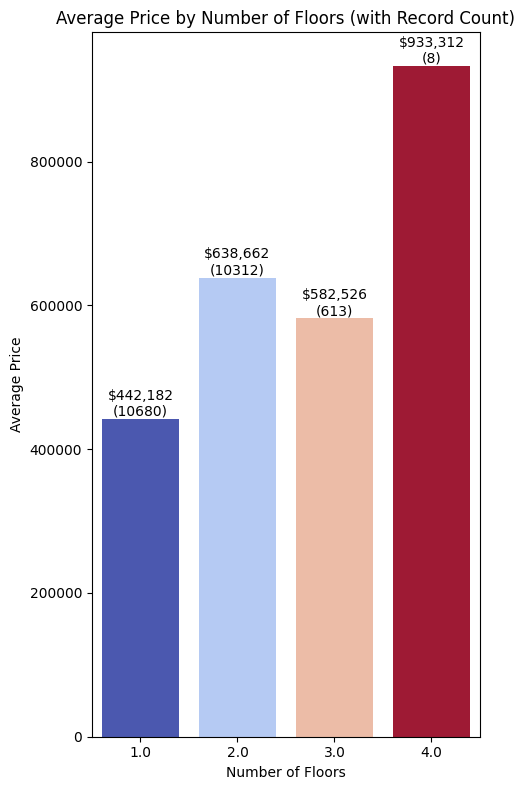

In [53]:
#Convert Floors to Whole Numbers:
# Round the number of floors to the nearest whole number
df['floors'] = df['floors'].round()

# Recompute the average price and count for the new rounded floors
floor_price = df.groupby('floors').agg({'price': 'mean', 'floors': 'size'}) # Removed reset_index() here
floor_price = floor_price.rename(columns={'floors': 'count'}).reset_index() # Added reset_index() here
floor_price.columns = ['floors', 'avg_price', 'count']

# Create the bar plot again
plt.figure(figsize=(5,8))
bars = sns.barplot(x='floors', y='avg_price', hue='floors', data=floor_price, palette='coolwarm', legend=False)

# Add average price and count of records above each bar
for index, bar in enumerate(bars.patches):
    height = bar.get_height()  # Get height of the bar (average price)
    count = floor_price['count'].iloc[index]  # Get the count of records for the respective floor
    avg_price = floor_price['avg_price'].iloc[index]  # Get the average price
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'${avg_price:,.0f}\n({count})',
             ha='center', va='bottom')

# Add labels and title
plt.xlabel('Number of Floors')
plt.ylabel('Average Price')
plt.title('Average Price by Number of Floors (with Record Count)')

# Display the plot
plt.tight_layout()
plt.show()

the prices of homes with 4 floors are higher in price but only with 8 records
2 floors seem more prefered by people as their price is relatively high and the count of records 10312

1 floor homes count recod are high . people prefer to live on one floor more?